In [1]:
# ============================================================
# Notebook 01 — Generación de datos simulados
# Sistema de detección de apnea del sueño
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Semilla para reproducibilidad
np.random.seed(42)

print("✓ Librerías cargadas correctamente")

✓ Librerías cargadas correctamente


In [2]:
# ============================================================
# Parámetros del sistema
# ============================================================

FRECUENCIA_MUESTREO = 10      # lecturas por segundo (Hz)
DURACION_VENTANA    = 30      # segundos por muestra
MUESTRAS_VENTANA    = FRECUENCIA_MUESTREO * DURACION_VENTANA  # 300 puntos

NUM_MUESTRAS_NORMAL  = 300    # ejemplos de respiración normal
NUM_MUESTRAS_LEVE    = 150    # ejemplos de apnea leve
NUM_MUESTRAS_SEVERA  = 150    # ejemplos de apnea severa

print(f"✓ Cada ventana tiene {MUESTRAS_VENTANA} puntos de datos")
print(f"✓ Total de ejemplos a generar: {NUM_MUESTRAS_NORMAL + NUM_MUESTRAS_LEVE + NUM_MUESTRAS_SEVERA}")
```

SyntaxError: invalid syntax (876559674.py, line 15)

In [3]:
# ============================================================
# Parámetros del sistema
# ============================================================

FRECUENCIA_MUESTREO = 10      # lecturas por segundo (Hz)
DURACION_VENTANA    = 30      # segundos por muestra
MUESTRAS_VENTANA    = FRECUENCIA_MUESTREO * DURACION_VENTANA  # 300 puntos

NUM_MUESTRAS_NORMAL  = 300    # ejemplos de respiración normal
NUM_MUESTRAS_LEVE    = 150    # ejemplos de apnea leve
NUM_MUESTRAS_SEVERA  = 150    # ejemplos de apnea severa

print(f"✓ Cada ventana tiene {MUESTRAS_VENTANA} puntos de datos")
print(f"✓ Total de ejemplos a generar: {NUM_MUESTRAS_NORMAL + NUM_MUESTRAS_LEVE + NUM_MUESTRAS_SEVERA}")



✓ Cada ventana tiene 300 puntos de datos
✓ Total de ejemplos a generar: 600


In [4]:
# ============================================================
# Funciones generadoras de señales respiratorias
# ============================================================

def generar_respiracion_normal(n_muestras, n_puntos):
    """
    Respiración normal: 12-20 ciclos por minuto.
    Señal sinusoidal regular con pequeño ruido natural.
    """
    datos = []
    for _ in range(n_muestras):
        t = np.linspace(0, 30, n_puntos)
        
        # Frecuencia entre 12 y 20 respiraciones por minuto
        frecuencia = np.random.uniform(12, 20) / 60
        amplitud   = np.random.uniform(0.8, 1.2)
        ruido      = np.random.normal(0, 0.05, n_puntos)
        
        senal = amplitud * np.sin(2 * np.pi * frecuencia * t) + ruido
        datos.append(senal)
    
    return np.array(datos)


def generar_apnea_leve(n_muestras, n_puntos):
    """
    Apnea leve: pausas de 10 a 20 segundos intercaladas
    con respiración casi normal.
    """
    datos = []
    for _ in range(n_muestras):
        t = np.linspace(0, 30, n_puntos)
        frecuencia = np.random.uniform(10, 15) / 60
        amplitud   = np.random.uniform(0.6, 1.0)
        ruido      = np.random.normal(0, 0.05, n_puntos)
        
        senal = amplitud * np.sin(2 * np.pi * frecuencia * t) + ruido
        
        # Insertar pausa de 10 a 20 segundos
        duracion_pausa  = np.random.randint(10, 20)
        inicio_pausa    = np.random.randint(0, 30 - duracion_pausa)
        idx_inicio      = int(inicio_pausa * n_puntos / 30)
        idx_fin         = int((inicio_pausa + duracion_pausa) * n_puntos / 30)
        senal[idx_inicio:idx_fin] = np.random.normal(0, 0.02, idx_fin - idx_inicio)
        
        datos.append(senal)
    
    return np.array(datos)


def generar_apnea_severa(n_muestras, n_puntos):
    """
    Apnea severa: pausas de 30 segundos o más.
    Señal casi plana con respiración débil al recuperarse.
    """
    datos = []
    for _ in range(n_muestras):
        t = np.linspace(0, 30, n_puntos)
        frecuencia = np.random.uniform(6, 10) / 60
        amplitud   = np.random.uniform(0.3, 0.6)
        ruido      = np.random.normal(0, 0.05, n_puntos)
        
        senal = amplitud * np.sin(2 * np.pi * frecuencia * t) + ruido
        
        # Pausa severa: ocupa la mayor parte de la ventana
        duracion_pausa = np.random.randint(20, 28)
        inicio_pausa   = np.random.randint(0, 30 - duracion_pausa)
        idx_inicio     = int(inicio_pausa * n_puntos / 30)
        idx_fin        = int((inicio_pausa + duracion_pausa) * n_puntos / 30)
        senal[idx_inicio:idx_fin] = np.random.normal(0, 0.01, idx_fin - idx_inicio)
        
        datos.append(senal)
    
    return np.array(datos)


print("✓ Funciones generadoras definidas correctamente")

✓ Funciones generadoras definidas correctamente


In [5]:
# ============================================================
# Generar los datos
# ============================================================

print("Generando datos...")

X_normal = generar_respiracion_normal(NUM_MUESTRAS_NORMAL, MUESTRAS_VENTANA)
X_leve   = generar_apnea_leve(NUM_MUESTRAS_LEVE,   MUESTRAS_VENTANA)
X_severa = generar_apnea_severa(NUM_MUESTRAS_SEVERA, MUESTRAS_VENTANA)

# Etiquetas: 0 = normal, 1 = apnea leve, 2 = apnea severa
y_normal = np.zeros(NUM_MUESTRAS_NORMAL, dtype=int)
y_leve   = np.ones(NUM_MUESTRAS_LEVE,   dtype=int)
y_severa = np.full(NUM_MUESTRAS_SEVERA,  2, dtype=int)

# Unir todo en un solo dataset
X = np.vstack([X_normal, X_leve, X_severa])
y = np.concatenate([y_normal, y_leve, y_severa])

print(f"✓ Forma del dataset X: {X.shape}")
print(f"✓ Forma de etiquetas y: {y.shape}")
print(f"✓ Clases: {np.unique(y, return_counts=True)}")

Generando datos...
✓ Forma del dataset X: (600, 300)
✓ Forma de etiquetas y: (600,)
✓ Clases: (array([0, 1, 2]), array([300, 150, 150]))


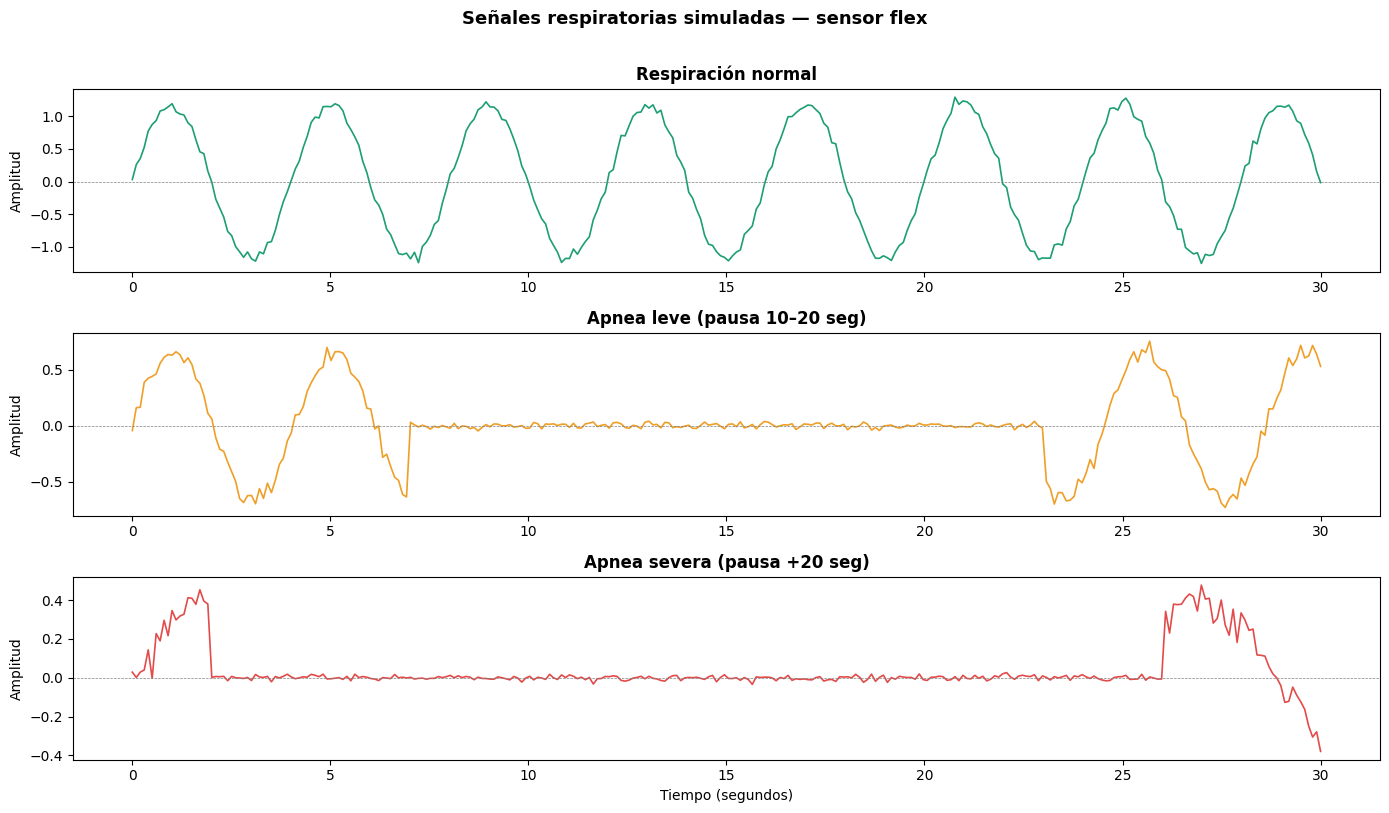

✓ Gráfica guardada en data/simulated/ejemplo_senales.png


In [6]:
# ============================================================
# Visualización de las señales
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(14, 8))
t = np.linspace(0, 30, MUESTRAS_VENTANA)

# Respiración normal
axes[0].plot(t, X_normal[0], color='#1D9E75', linewidth=1.2)
axes[0].set_title('Respiración normal', fontweight='bold')
axes[0].set_ylabel('Amplitud')
axes[0].axhline(0, color='gray', linewidth=0.5, linestyle='--')

# Apnea leve
axes[1].plot(t, X_leve[0], color='#EF9F27', linewidth=1.2)
axes[1].set_title('Apnea leve (pausa 10–20 seg)', fontweight='bold')
axes[1].set_ylabel('Amplitud')
axes[1].axhline(0, color='gray', linewidth=0.5, linestyle='--')

# Apnea severa
axes[2].plot(t, X_severa[0], color='#E24B4A', linewidth=1.2)
axes[2].set_title('Apnea severa (pausa +20 seg)', fontweight='bold')
axes[2].set_ylabel('Amplitud')
axes[2].set_xlabel('Tiempo (segundos)')
axes[2].axhline(0, color='gray', linewidth=0.5, linestyle='--')

plt.suptitle('Señales respiratorias simuladas — sensor flex', 
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/simulated/ejemplo_senales.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Gráfica guardada en data/simulated/ejemplo_senales.png")

In [7]:
# ============================================================
# Guardar los datos en disco
# ============================================================

# Crear carpeta si no existe
ruta = Path('../data/simulated')
ruta.mkdir(parents=True, exist_ok=True)

# Convertir a DataFrame y guardar
df_X = pd.DataFrame(X)
df_y = pd.Series(y, name='etiqueta')

df_X.to_csv(ruta / 'X_datos.csv', index=False)
df_y.to_csv(ruta / 'y_etiquetas.csv', index=False)

print(f"✓ X_datos.csv     — {df_X.shape[0]} filas x {df_X.shape[1]} columnas")
print(f"✓ y_etiquetas.csv — {df_y.shape[0]} etiquetas")
print(f"✓ Distribución de clases:")
print(f"   0 = Normal:       {(df_y == 0).sum()} ejemplos")
print(f"   1 = Apnea leve:   {(df_y == 1).sum()} ejemplos")
print(f"   2 = Apnea severa: {(df_y == 2).sum()} ejemplos")
print("\n✓ Datos guardados correctamente en data/simulated/")

✓ X_datos.csv     — 600 filas x 300 columnas
✓ y_etiquetas.csv — 600 etiquetas
✓ Distribución de clases:
   0 = Normal:       300 ejemplos
   1 = Apnea leve:   150 ejemplos
   2 = Apnea severa: 150 ejemplos

✓ Datos guardados correctamente en data/simulated/
